# Fase 4 — ETL: Extract, Transform, Load

**Proyecto Final — Gestión de Datos (UAX) · 3º Ingeniería Matemática**  
**Paleta:** Verde — cada fase del proyecto usa una paleta distinta para identificación visual rápida.

Este notebook mueve los datos desde el OLTP (`public`) hasta el Data Warehouse (`dwh`)
aplicando las transformaciones y correcciones detectadas durante el EDA.  
El proceso es **idempotente**: `TRUNCATE RESTART IDENTITY CASCADE` garantiza que
ejecutarlo varias veces siempre produce exactamente el mismo resultado.

```
OLTP (public · 17 tablas)  ──▶  Python / Pandas  ──▶  DWH (dwh · 7 tablas)
       42.555 líneas                 ETL                  fact + 6 dims
```

---

## Tabla de contenidos

| # | Sección | Tabla DWH | Filas esperadas |
|---|---------|-----------|----------------|
| 1 | Imports, paleta y conexión | — | — |
| 2 | Extracción del OLTP | — | 10 tablas fuente |
| 3 | Dimensión Tiempo | `dim_date` | 2.191 |
| 4 | Dimensión Cliente | `dim_customer` | 5.750 |
| 5 | Dimensión Producto | `dim_product` | 50 |
| 6 | Dimensión Tienda | `dim_store` | 20 |
| 7 | Dimensión Oferta + Motivo devolución | `dim_offer` · `dim_return_reason` | 2 · 7 |
| 8 | Tabla de Hechos | `fact_sales` | 42.555 |
| 9 | Validaciones pre-carga | — | — |
| 10 | Carga al DWH | Todas las tablas | — |
| 11 | Verificación final | — | — |

---
## 1. Imports, paleta y conexión

Conexion OK: PostgreSQL 18.3 (Debian 18.3-1.pgdg13+1) on aarch64-unk
Schemas disponibles: ['dwh', 'public']
Tabla sale (OLTP): 20,000 filas

Paleta ETL (verde):


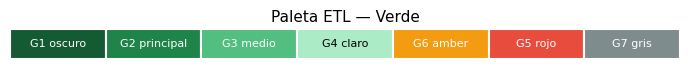

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlalchemy as sa
from sqlalchemy import text

warnings.filterwarnings('ignore')
os.makedirs('graficos', exist_ok=True)

# ── PALETA ETL (VERDE) ───────────────────────────────────────────────────────
G1 = '#145A32'   # verde muy oscuro  — barras principales / títulos
G2 = '#1E8449'   # verde oscuro      — secundario
G3 = '#52BE80'   # verde medio       — tercer nivel
G4 = '#ABEBC6'   # verde claro       — cuarto nivel
G5 = '#E74C3C'   # rojo              — errores / anomalías
G6 = '#F39C12'   # ámbar             — avisos / flags
G7 = '#7F8C8D'   # gris              — neutro / secundario
PALETTE_ETL = [G1, G2, G3, G4, G6, G5]
SEQ_CMAP    = 'Greens'

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F9FBE7',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'DejaVu Sans',
})

# ── CONEXIÓN ─────────────────────────────────────────────────────────────────
HOST, PORT, DB_NAME, USER, PASSWORD = 'localhost', 5432, 'Proyecto_final', 'admin', 'admin'
engine = sa.create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}')

with engine.connect() as conn:
    ver = conn.execute(text('SELECT version()')).fetchone()[0][:55]
    schemas = [r[0] for r in conn.execute(text(
        "SELECT schema_name FROM information_schema.schemata "
        "WHERE schema_name IN ('public','dwh') ORDER BY schema_name"
    ))]
    n_sale = conn.execute(text('SELECT COUNT(*) FROM sale')).scalar()
    print(f'Conexion OK: {ver}')
    print(f'Schemas disponibles: {schemas}')
    print(f'Tabla sale (OLTP): {n_sale:,} filas')

print('\nPaleta ETL (verde):')
fig, ax = plt.subplots(figsize=(7, 0.8))
colors = [G1, G2, G3, G4, G6, G5, G7]
labels = ['G1 oscuro', 'G2 principal', 'G3 medio', 'G4 claro', 'G6 amber', 'G5 rojo', 'G7 gris']
for i, (c, l) in enumerate(zip(colors, labels)):
    ax.barh(0, 1, left=i, color=c, edgecolor='white', linewidth=1.5)
    ax.text(i + 0.5, 0, l, ha='center', va='center', fontsize=8,
            color='white' if i < 3 else ('black' if i == 3 else 'white'))
ax.set_xlim(0, 7)
ax.axis('off')
ax.set_title('Paleta ETL — Verde', fontsize=11, pad=4)
plt.tight_layout()
plt.savefig('graficos/etl_00_paleta.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

---
## 2. Extracción del OLTP

Leemos las 10 tablas fuente necesarias para construir las 7 tablas del DWH.
Los datos **no se modifican en el OLTP**: todas las transformaciones ocurren en memoria (Pandas).

Extrayendo datos del OLTP...
  customer               5750 filas
  sale                  20000 filas
  sale_item             42555 filas
  product                  50 filas
  central_product          49 filas
  store                    20 filas
  city_zone                42 filas
  offer                     1 filas
  return_item            2330 filas
  return_reason             6 filas

Total filas extraidas: 70,803


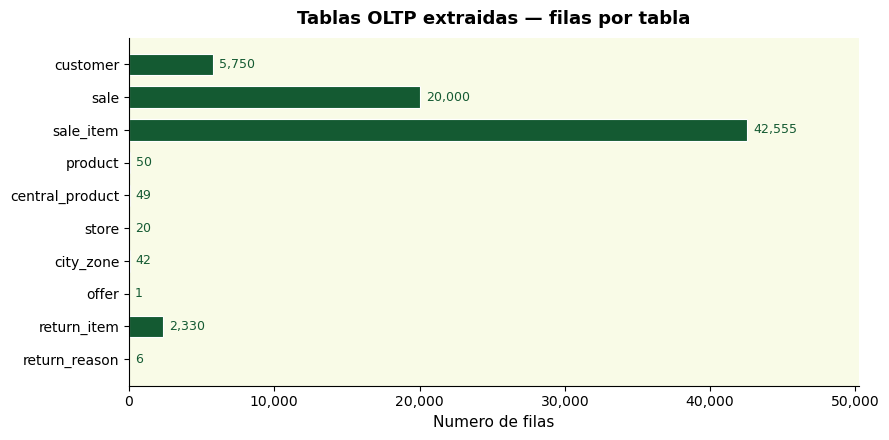

In [2]:
print('Extrayendo datos del OLTP...')

df_customer      = pd.read_sql('SELECT * FROM customer',        engine)
df_sale          = pd.read_sql('SELECT * FROM sale',            engine)
df_sale_item     = pd.read_sql('SELECT * FROM sale_item',       engine)
df_product       = pd.read_sql('SELECT * FROM product',         engine)
df_cprod         = pd.read_sql('SELECT * FROM central_product', engine)
df_store         = pd.read_sql('SELECT * FROM store',           engine)
df_cityzone      = pd.read_sql('SELECT * FROM city_zone',       engine)
df_offer         = pd.read_sql('SELECT * FROM offer',           engine)
df_return        = pd.read_sql('SELECT * FROM return_item',     engine)
df_return_reason = pd.read_sql('SELECT * FROM return_reason',   engine)

tablas = {
    'customer':       len(df_customer),
    'sale':           len(df_sale),
    'sale_item':      len(df_sale_item),
    'product':        len(df_product),
    'central_product':len(df_cprod),
    'store':          len(df_store),
    'city_zone':      len(df_cityzone),
    'offer':          len(df_offer),
    'return_item':    len(df_return),
    'return_reason':  len(df_return_reason),
}
for nombre, n in tablas.items():
    print(f'  {nombre:<20} {n:>6} filas')
print(f'\nTotal filas extraidas: {sum(tablas.values()):,}')

# ── Visualización ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
nombres = list(tablas.keys())
valores = list(tablas.values())
colores = [G1 if v > 1000 else (G2 if v > 100 else G3) for v in valores]

bars = ax.barh(nombres[::-1], valores[::-1], color=colores[::-1],
               edgecolor='white', linewidth=0.8, height=0.65)
for bar, val in zip(bars, valores[::-1]):
    ax.text(bar.get_width() + max(valores) * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9, color=G1)

ax.set_xlabel('Numero de filas')
ax.set_title('Tablas OLTP extraidas — filas por tabla', fontweight='bold', pad=10)
ax.set_xlim(0, max(valores) * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('graficos/etl_02_extraccion.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

---
## 3. `dim_date` — Dimensión Tiempo

La dimensión fecha **no existe en el OLTP**: la generamos sintéticamente cubriendo
todo el rango de ventas registradas (2020-01-01 a 2025-12-30).  
Cada día genera una fila con sus atributos temporales: año, trimestre, mes, semana,
día de semana, nombre del día, si es fin de semana, si es fin de mes.

> `date_id` se almacena como entero en formato `YYYYMMDD` (ej: `20230415`),
> lo que permite filtros eficientes sin conversión de tipo.

In [3]:
fecha_inicio = pd.to_datetime(df_sale['sale_date']).dt.date.min()
fecha_fin    = pd.to_datetime(df_sale['sale_date']).dt.date.max()
print(f'Rango de ventas: {fecha_inicio} → {fecha_fin}')

fechas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

MESES = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
         'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
DIAS  = ['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo']

dim_date = pd.DataFrame({
    'date_id':      fechas.strftime('%Y%m%d').astype(int),
    'date':         fechas.date,
    'year':         fechas.year.astype('int16'),
    'quarter':      fechas.quarter.astype('int16'),
    'month':        fechas.month.astype('int16'),
    'month_name':   [MESES[m-1] for m in fechas.month],
    'week':         fechas.isocalendar().week.astype('int16').values,
    'day_of_month': fechas.day.astype('int16'),
    'day_of_week':  (fechas.dayofweek + 1).astype('int16'),  # 1=Lunes, 7=Domingo
    'day_name':     [DIAS[d] for d in fechas.dayofweek],
    'is_weekend':   fechas.dayofweek >= 5,
    'is_month_end': fechas.is_month_end,
})

print(f'dim_date: {len(dim_date)} filas ({dim_date["year"].min()}–{dim_date["year"].max()})')
print(f'  Columnas: {list(dim_date.columns)}')
print(f'  Días laborables: {(~dim_date["is_weekend"]).sum():,}')
print(f'  Fines de semana: {dim_date["is_weekend"].sum():,}')
dim_date.head(3)

Rango de ventas: 2020-01-01 → 2025-12-30
dim_date: 2191 filas (2020–2025)
  Columnas: ['date_id', 'date', 'year', 'quarter', 'month', 'month_name', 'week', 'day_of_month', 'day_of_week', 'day_name', 'is_weekend', 'is_month_end']
  Días laborables: 1,565
  Fines de semana: 626


,date_id,date,year,quarter,month,month_name,week,day_of_month,day_of_week,day_name,is_weekend,is_month_end
0,20200101,2020-01-01,2020,1,1,Enero,1,1,3,Miercoles,False,False
1,20200102,2020-01-02,2020,1,1,Enero,1,2,4,Jueves,False,False
2,20200103,2020-01-03,2020,1,1,Enero,1,3,5,Viernes,False,False


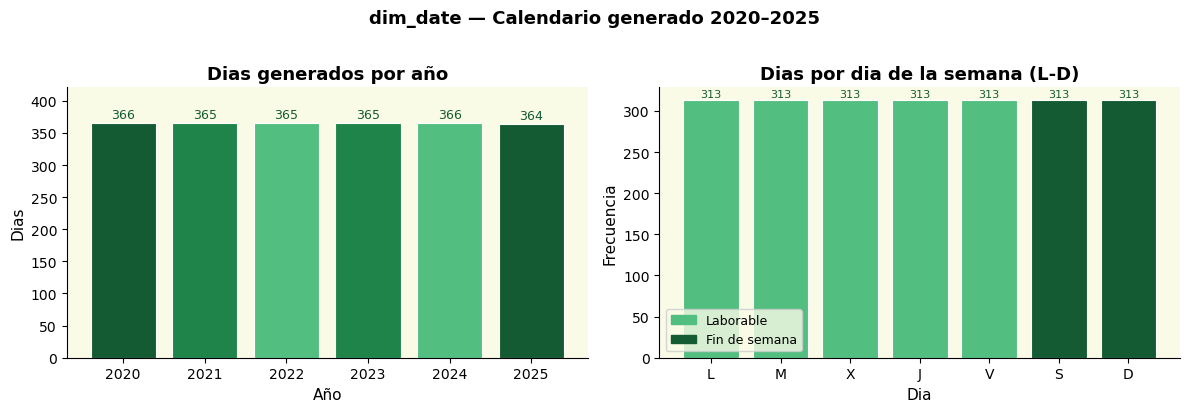

Guardado: graficos/etl_03_dimdate.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Plot 1: días por año ─────────────────────────────────────────────────────
dias_anio = dim_date.groupby('year').size().reset_index(name='dias')
colores_anio = [G1, G2, G3, G2, G3, G1]
bars = axes[0].bar(dias_anio['year'].astype(str), dias_anio['dias'],
                   color=colores_anio, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, dias_anio['dias']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=9, color=G1)
axes[0].set_title('Dias generados por año', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Dias')
axes[0].set_ylim(0, dias_anio['dias'].max() * 1.15)

# ── Plot 2: distribución día de semana ────────────────────────────────────────
dias_semana = dim_date.groupby('day_name').size()
orden_dias  = ['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo']
dias_semana = dias_semana.reindex(orden_dias)
color_semana = [G1 if d in ['Sabado','Domingo'] else G3 for d in orden_dias]
bars2 = axes[1].bar(range(7), dias_semana.values, color=color_semana,
                    edgecolor='white', linewidth=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['L','M','X','J','V','S','D'], fontsize=10)
for bar, val in zip(bars2, dias_semana.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=8, color=G1)
axes[1].set_title('Dias por dia de la semana (L-D)', fontweight='bold')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Frecuencia')
lunes_patch  = mpatches.Patch(color=G3, label='Laborable')
finde_patch  = mpatches.Patch(color=G1, label='Fin de semana')
axes[1].legend(handles=[lunes_patch, finde_patch], fontsize=9)

fig.suptitle('dim_date — Calendario generado 2020–2025', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/etl_03_dimdate.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print(f'Guardado: graficos/etl_03_dimdate.png')

---
## 4. `dim_customer` — Dimensión Cliente

**Regla fundamental:** nunca eliminar clientes. Los datos incorrectos se imputan.

Transformaciones aplicadas:

| Campo | Problema detectado | Solución |
|-------|--------------------|----------|
| `email` | Espacios en blanco (apellidos compuestos) | `strip()` |
| `email` | ~115 NULL | Imputar `cliente_<ID>@unknown.com` |
| `first_name` / `last_name` | Algunos NULL | Imputar `"Desconocido"` |
| `phone` | Algunos NULL | Imputar `"000000000"` |
| `created_at` | ~5.000 fechas futuras (>2025) | Sustituir por `first_purchase_date` |
| `customer_age_days` | 0 en clientes con una sola compra | Imputar con mediana de multi-compra |

> `customer_age_days = last_purchase_date − first_purchase_date` (días entre primera y última compra).  
> Se usa como **R_t** en la fórmula CLTV de la Fase 5.

In [5]:
dim_customer = df_customer.copy()

# ── Conteo de nulos ANTES ─────────────────────────────────────────────────
campos_vigilar = ['first_name', 'last_name', 'email', 'phone']
nulos_antes = {c: dim_customer[c].isnull().sum() for c in campos_vigilar}

# ── Imputar nulos ─────────────────────────────────────────────────────────
dim_customer['first_name'] = dim_customer['first_name'].fillna('Desconocido')
dim_customer['last_name']  = dim_customer['last_name'].fillna('Desconocido')
dim_customer['last_name2'] = dim_customer['last_name2'].fillna('')
dim_customer['email']      = dim_customer['email'].fillna(
    'cliente_' + dim_customer['customer_id'].astype(str) + '@unknown.com'
)
dim_customer['phone'] = dim_customer['phone'].fillna('000000000')

# ── Corregir emails con espacios (apellidos compuestos: "Del Rio") ────────
n_email_esp = dim_customer['email'].str.contains(' ', na=False).sum()
dim_customer['email'] = dim_customer['email'].str.replace(' ', '', regex=False)
print(f'Emails con espacios corregidos: {n_email_esp}')

# ── Nombre completo ───────────────────────────────────────────────────────
dim_customer['full_name'] = (
    dim_customer['first_name'] + ' ' +
    dim_customer['last_name']  + ' ' +
    dim_customer['last_name2']
).str.strip()

# ── Primera y última compra (desde sale) ──────────────────────────────────
df_sale['sale_date'] = pd.to_datetime(df_sale['sale_date'])
compras = df_sale.groupby('customer_id').agg(
    first_purchase_date=('sale_date', lambda x: x.min().date()),
    last_purchase_date= ('sale_date', lambda x: x.max().date()),
).reset_index()
dim_customer = dim_customer.merge(compras, on='customer_id', how='left')

# ── Corregir created_at futura (>2025) ────────────────────────────────────
dim_customer['created_at'] = pd.to_datetime(dim_customer['created_at'])
mask_futuro = dim_customer['created_at'] > '2025-12-31'
dim_customer.loc[mask_futuro, 'created_at'] = pd.to_datetime(
    dim_customer.loc[mask_futuro, 'first_purchase_date']
)
print(f'Clientes con created_at futuro corregido: {mask_futuro.sum():,}')

# ── customer_age_days = last_purchase - first_purchase ────────────────────
dim_customer['customer_age_days'] = (
    pd.to_datetime(dim_customer['last_purchase_date']) -
    pd.to_datetime(dim_customer['first_purchase_date'])
).dt.days.fillna(0).astype(int)

mediana_age = int(dim_customer.loc[
    dim_customer['customer_age_days'] > 0, 'customer_age_days'
].median())
n_single = (dim_customer['customer_age_days'] == 0).sum()
dim_customer['customer_age_days'] = dim_customer['customer_age_days'].replace(0, mediana_age)
print(f'Clientes con unica compra (age=0 → mediana {mediana_age} dias): {n_single:,}')

# ── Columnas finales ──────────────────────────────────────────────────────
dim_customer = dim_customer[[
    'customer_id','first_name','last_name','last_name2','full_name',
    'email','phone','created_at',
    'first_purchase_date','last_purchase_date','customer_age_days'
]]

nulos_despues = {c: dim_customer[c].isnull().sum() for c in campos_vigilar}

print(f'\ndim_customer: {len(dim_customer):,} filas')
print(f'Nulos restantes en campos clave: {sum(nulos_despues.values())}')
dim_customer.head(3)

Emails con espacios corregidos: 98
Clientes con created_at futuro corregido: 5,000
Clientes con unica compra (age=0 → mediana 1998 dias): 5,000

dim_customer: 5,750 filas
Nulos restantes en campos clave: 0


,customer_id,first_name,last_name,last_name2,full_name,email,phone,created_at,first_purchase_date,last_purchase_date,customer_age_days
0,1,Marta,Ruiz,García,Marta Ruiz García,marta.ruiz1@example.com,+34 6987791,2018-11-15 04:51:29.131242,2020-06-29,2025-10-01,1920
1,2,Alejandro,López,López,Alejandro López López,alejandro.lópez2@example.com,+34 669926134,2018-09-07 20:45:28.751233,2020-03-02,2025-10-30,2068
2,3,Alejandro,López,Álvarez,Alejandro López Álvarez,alejandro.lópez3@example.com,+34 661558537,2019-02-09 06:54:03.656551,2020-08-17,2025-11-07,1908


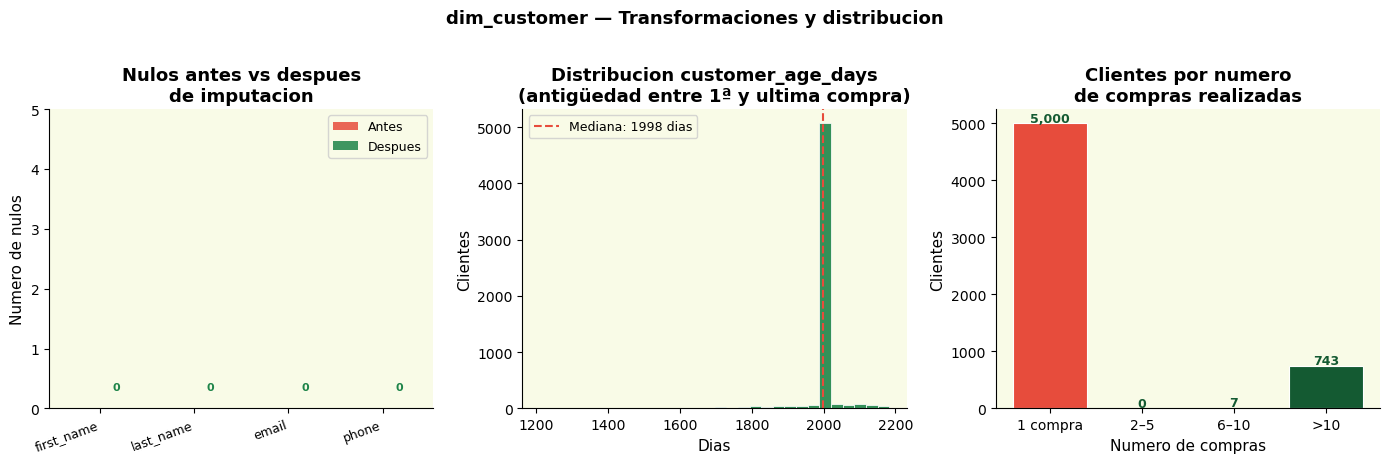

Guardado: graficos/etl_04_dimcustomer.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Plot 1: nulos antes vs despues ────────────────────────────────────────
x = np.arange(len(campos_vigilar))
w = 0.35
axes[0].bar(x - w/2, [nulos_antes[c] for c in campos_vigilar],
            width=w, color=G5, label='Antes', alpha=0.85)
axes[0].bar(x + w/2, [nulos_despues[c] for c in campos_vigilar],
            width=w, color=G2, label='Despues', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(campos_vigilar, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Nulos antes vs despues\nde imputacion', fontweight='bold')
axes[0].set_ylabel('Numero de nulos')
axes[0].legend(fontsize=9)
max_null = max(nulos_antes.values()) if nulos_antes.values() else 1
axes[0].set_ylim(0, max(max_null * 1.3, 5))
for xi, c in zip(x, campos_vigilar):
    v = nulos_antes[c]
    if v > 0:
        axes[0].text(xi - w/2, v + max_null * 0.03, str(v),
                     ha='center', fontsize=8, color=G5, fontweight='bold')
    axes[0].text(xi + w/2, 0.3, '0', ha='center', fontsize=8, color=G2, fontweight='bold')

# ── Plot 2: distribución customer_age_days ───────────────────────────────
axes[1].hist(dim_customer['customer_age_days'], bins=30, color=G2,
             edgecolor='white', linewidth=0.6, alpha=0.9)
mediana = dim_customer['customer_age_days'].median()
axes[1].axvline(mediana, color=G5, linestyle='--', linewidth=1.5,
                label=f'Mediana: {int(mediana)} dias')
axes[1].set_title('Distribucion customer_age_days\n(antigüedad entre 1ª y ultima compra)', fontweight='bold')
axes[1].set_xlabel('Dias')
axes[1].set_ylabel('Clientes')
axes[1].legend(fontsize=9)

# ── Plot 3: clientes por numero de compras (1 vs multiple) ───────────────
num_compras = df_sale.groupby('customer_id').size().reset_index(name='n_compras')
num_compras['grupo'] = num_compras['n_compras'].apply(
    lambda x: '1 compra' if x == 1 else ('2–5' if x <= 5 else ('6–10' if x <= 10 else '>10'))
)
conteo = num_compras['grupo'].value_counts().reindex(
    ['1 compra', '2–5', '6–10', '>10'], fill_value=0
)
colores_bar = [G5, G4, G3, G1]
bars3 = axes[2].bar(conteo.index, conteo.values, color=colores_bar,
                    edgecolor='white', linewidth=0.8)
for bar, val in zip(bars3, conteo.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=9, color=G1, fontweight='bold')
axes[2].set_title('Clientes por numero\nde compras realizadas', fontweight='bold')
axes[2].set_xlabel('Numero de compras')
axes[2].set_ylabel('Clientes')

fig.suptitle('dim_customer — Transformaciones y distribucion', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/etl_04_dimcustomer.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/etl_04_dimcustomer.png')

---
## 5. `dim_product` — Dimensión Producto

La tabla `product` contiene los 50 productos de tienda (con precio de venta),
pero no el coste unitario. Ese dato vive en `central_product` (49 filas; 1 producto
no tiene coste).

Transformaciones:
- **Cruce** `product` ↔ `central_product` por `product_id` (método primario)
- **Imputación** del `unit_cost` faltante con la mediana de su categoría (`Diagnóstico` ≈ 59,99 €)
- **Corrección** de la categoría del `product_id=29`: `"Domótica Salud"` → `"Diagnóstico"`
- **Cálculo** de `margin_pct = (price - unit_cost) / price × 100`

In [7]:
df_product['name_norm'] = df_product['name'].str.strip().str.lower()
df_cprod['name_norm']   = df_cprod['name'].str.strip().str.lower()

def normalizar_categoria(txt):
    if pd.isna(txt):
        return txt
    rep = str(txt).strip().lower()
    return (rep
        .replace('á', 'a')
        .replace('é', 'e')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u'))

# ── Cruce por product_id ──────────────────────────────────────────────────
dim_product = df_product.merge(
    df_cprod[['product_id', 'unit_cost']].rename(columns={'product_id': 'central_id'}),
    left_on='product_id', right_on='central_id', how='left'
).drop(columns=['central_id', 'name_norm'])

n_sin_coste = dim_product['unit_cost'].isna().sum()
print(f'Productos con unit_cost tras cruce: {50 - n_sin_coste}/50')
print(f'Productos sin coste (a imputar):    {n_sin_coste}')

# ── Corrección de categoría (product_id=29) ───────────────────────────────
n_cat = (dim_product['product_id'] == 29).sum()
if n_cat > 0:
    dim_product.loc[dim_product['product_id'] == 29, 'category'] = 'Diagnostico'
    print('Categoria corregida: product_id=29  "Domotica Salud" → "Diagnostico"')

# ── Imputación de unit_cost con mediana de la categoría ──────────────────
df_cprod_cat = pd.read_sql("""
    SELECT cp.unit_cost, c.name AS category_name
    FROM central_product cp
    JOIN category c ON cp.category_id = c.category_id
""", engine)
df_cprod_cat['category_norm'] = df_cprod_cat['category_name'].apply(normalizar_categoria)
dim_product['category_norm'] = dim_product['category'].apply(normalizar_categoria)
mediana_diag   = df_cprod_cat.loc[df_cprod_cat['category_norm'] == 'diagnostico', 'unit_cost'].median()
mediana_global = df_cprod['unit_cost'].median()
if pd.isna(mediana_diag):
    mediana_diag = mediana_global

dim_product['cost_imputed'] = dim_product['unit_cost'].isna()

def imputar_coste(row):
    if pd.notna(row['unit_cost']):
        return row['unit_cost']
    if row['category_norm'] == 'diagnostico':
        return mediana_diag
    return mediana_global

dim_product['unit_cost'] = dim_product.apply(imputar_coste, axis=1)

# ── Margen porcentual ─────────────────────────────────────────────────────
dim_product['margin_pct'] = (
    (dim_product['price'] - dim_product['unit_cost']) / dim_product['price'] * 100
).round(2)

# ── Columnas finales ──────────────────────────────────────────────────────
dim_product = dim_product[[
    'product_id','name','category','manufacturer',
    'price','unit_cost','margin_pct','cost_imputed'
]]

if dim_product['unit_cost'].isna().any():
    raise AssertionError('dim_product contiene unit_cost nulo tras la imputacion.')

print(f'\ndim_product: {len(dim_product)} filas')
print(f'Mediana Diagnostico = {mediana_diag:.2f} EUR | Mediana global = {mediana_global:.2f} EUR')
print(f'Margen medio: {dim_product["margin_pct"].mean():.1f}%')
dim_product[['product_id','name','category','price','unit_cost','margin_pct','cost_imputed']].head(5)

Productos con unit_cost tras cruce: 49/50
Productos sin coste (a imputar):    1
Categoria corregida: product_id=29  "Domotica Salud" → "Diagnostico"

dim_product: 50 filas
Mediana Diagnostico = 59.99 EUR | Mediana global = 59.94 EUR
Margen medio: 35.2%


,product_id,name,category,price,unit_cost,margin_pct,cost_imputed
0,1,Tensiómetro digital,Diagnóstico,59.99,35.99,40.01,False
1,2,Oxímetro de pulso,Diagnóstico,29.99,17.99,40.01,False
2,3,Termómetro infrarrojo,Diagnóstico,24.90,14.94,40.00,False
3,4,Báscula inteligente,Wellness,34.99,20.99,40.01,False
4,5,Monitor de glucosa,Diagnóstico,79.99,47.99,40.01,False


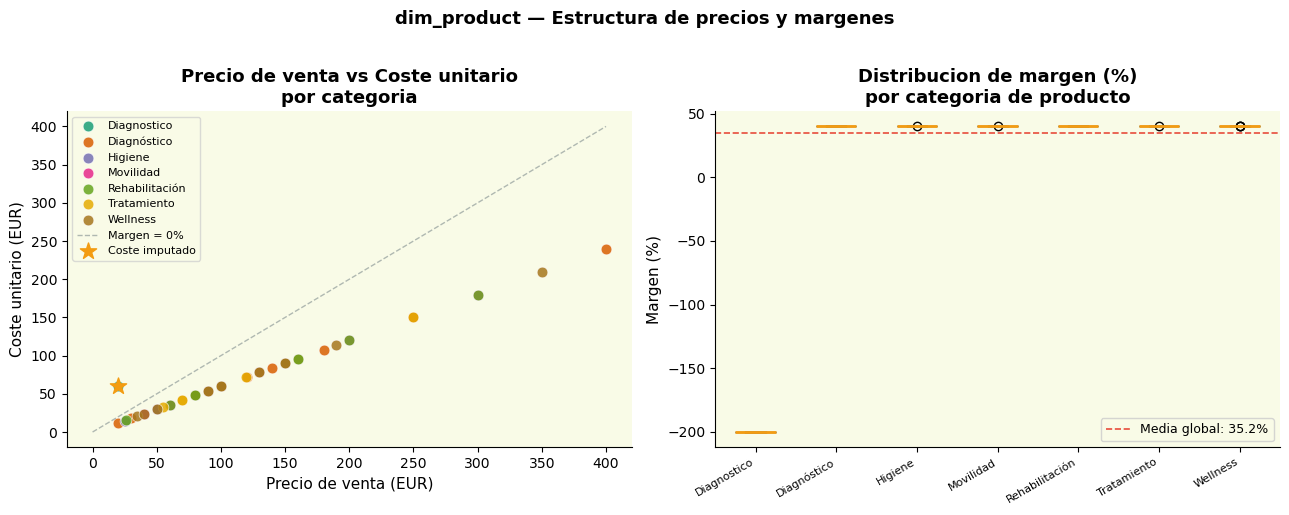

Guardado: graficos/etl_05_dimproduct.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categorias = dim_product['category'].unique()
# Generar tantos colores como categorías haya (no limitado a len(PALETTE_ETL))
n_cats = len(categorias)
palette_cats = sns.color_palette('Dark2', n_cats)
colores_cat = dict(zip(sorted(categorias), palette_cats))

# ── Plot 1: scatter price vs unit_cost por categoría ─────────────────────
for cat in sorted(categorias):
    sub = dim_product[dim_product['category'] == cat]
    axes[0].scatter(sub['price'], sub['unit_cost'],
                    color=colores_cat[cat], label=cat, s=60, alpha=0.85,
                    edgecolors='white', linewidths=0.5)

# Línea de margen = 0
max_precio = dim_product['price'].max()
axes[0].plot([0, max_precio], [0, max_precio], '--', color=G7, linewidth=1,
             label='Margen = 0%', alpha=0.6)

# Marcar el producto imputado
imp = dim_product[dim_product['cost_imputed']]
if len(imp) > 0:
    axes[0].scatter(imp['price'], imp['unit_cost'], color=G6, s=150,
                    marker='*', zorder=5, label='Coste imputado')

axes[0].set_xlabel('Precio de venta (EUR)')
axes[0].set_ylabel('Coste unitario (EUR)')
axes[0].set_title('Precio de venta vs Coste unitario\npor categoria', fontweight='bold')
axes[0].legend(fontsize=8, framealpha=0.7)

# ── Plot 2: boxplot margin_pct por categoría ──────────────────────────────
cats_orden = sorted(dim_product['category'].unique())
data_box = [dim_product.loc[dim_product['category'] == c, 'margin_pct'].values
            for c in cats_orden]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=False,
                     medianprops={'color': G6, 'linewidth': 2})
for patch, cat in zip(bp['boxes'], cats_orden):
    patch.set_facecolor(colores_cat[cat])
    patch.set_alpha(0.8)
axes[1].set_xticklabels(cats_orden, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Margen (%)')
axes[1].set_title('Distribucion de margen (%)\npor categoria de producto', fontweight='bold')
axes[1].axhline(dim_product['margin_pct'].mean(), color=G5, linestyle='--',
                linewidth=1.2, label=f'Media global: {dim_product["margin_pct"].mean():.1f}%')
axes[1].legend(fontsize=9)

fig.suptitle('dim_product — Estructura de precios y margenes', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/etl_05_dimproduct.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/etl_05_dimproduct.png')

---
## 6. `dim_store` — Dimensión Tienda

Las 20 tiendas están todas en Madrid. La tabla `store` no incluye información
geográfica más allá del código postal. La tabla `city_zone` nos proporciona:

- `district` — barrio (Retiro, Salamanca, Chamartín…)
- `area_type` — tipo de zona (`Céntrica` / `Periférica`)
- `zone_orientation` — orientación (Norte, Sur, Este, Oeste, Centro)

El enriquecimiento se hace por JOIN en `postal_code`.

dim_store: 20 filas
Tiendas sin zona asignada: 0

Distribucion por area_type:
area_type
Céntrica      10
Periférica    10

Distribucion por zone_orientation:
zone_orientation
Centro      8
Norte       4
Sureste     2
Noreste     2
Noroeste    1
Sur         1
Suroeste    1


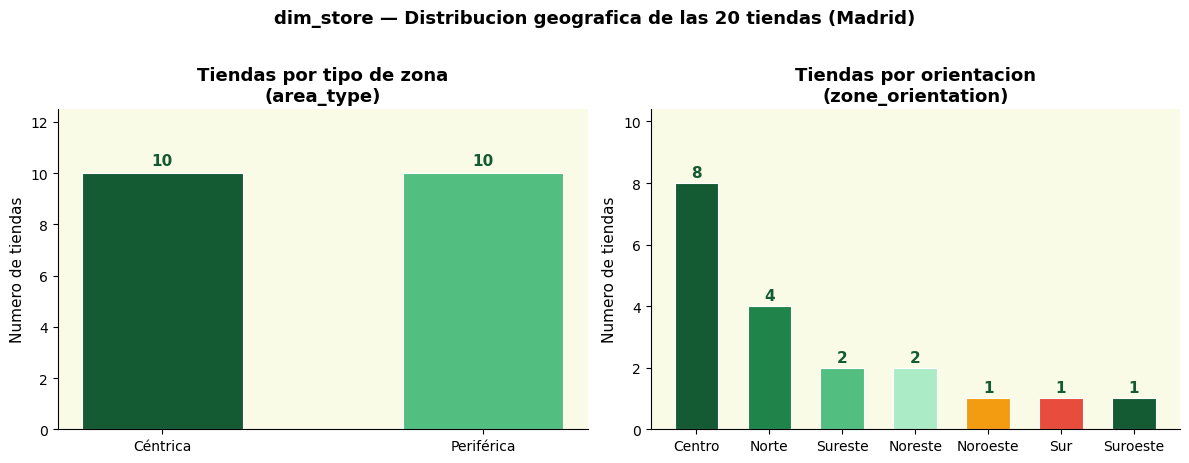

Guardado: graficos/etl_06_dimstore.png


,store_id,name,district,area_type,zone_orientation
0,1,Store Retiro,Retiro,Céntrica,Centro
1,2,Store Salamanca,Salamanca,Céntrica,Centro
2,3,Store Chamartín,Chamartín,Céntrica,Norte
3,4,Store La Latina,Centro,Céntrica,Centro
4,5,Store Sol,Centro,Céntrica,Centro


In [9]:
df_store['postal_code_norm']    = df_store['postal_code'].str.strip().str.zfill(5)
df_cityzone['postal_code_norm'] = df_cityzone['postal_code'].str.strip().str.zfill(5)

dim_store = df_store.merge(
    df_cityzone[['postal_code_norm','district','area_type','zone_orientation']],
    on='postal_code_norm', how='left'
)
dim_store = dim_store[[
    'store_id','name','address','city','postal_code',
    'district','area_type','zone_orientation',
    'latitude','longitude','opened_date'
]]

print(f'dim_store: {len(dim_store)} filas')
print(f'Tiendas sin zona asignada: {dim_store["district"].isna().sum()}')
print(f'\nDistribucion por area_type:')
print(dim_store['area_type'].value_counts().to_string())
print(f'\nDistribucion por zone_orientation:')
print(dim_store['zone_orientation'].value_counts().to_string())

# ── Visualización ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: tiendas por area_type
at = dim_store['area_type'].value_counts()
bars1 = axes[0].bar(at.index, at.values, color=[G1, G3][:len(at)],
                    edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars1, at.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=11, fontweight='bold', color=G1)
axes[0].set_title('Tiendas por tipo de zona\n(area_type)', fontweight='bold')
axes[0].set_ylabel('Numero de tiendas')
axes[0].set_ylim(0, at.max() * 1.25)

# Plot 2: tiendas por orientacion geografica
zo = dim_store['zone_orientation'].value_counts()
colores_zo = [PALETTE_ETL[i % len(PALETTE_ETL)] for i in range(len(zo))]
bars2 = axes[1].bar(zo.index, zo.values, color=colores_zo,
                    edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars2, zo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontsize=11, fontweight='bold', color=G1)
axes[1].set_title('Tiendas por orientacion\n(zone_orientation)', fontweight='bold')
axes[1].set_ylabel('Numero de tiendas')
axes[1].set_ylim(0, zo.max() * 1.3)

fig.suptitle('dim_store — Distribucion geografica de las 20 tiendas (Madrid)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/etl_06_dimstore.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/etl_06_dimstore.png')
dim_store[['store_id','name','district','area_type','zone_orientation']].head(5)

---
## 7. `dim_offer` y `dim_return_reason` — Filas centinela

Estas dos dimensiones son pequeñas (1 oferta real, 6 motivos de devolución),
pero requieren un tratamiento especial: la **fila centinela con `id = -1`**.

### ¿Por qué existe la fila -1?

En el OLTP, `sale_item.offer_id` es **100% nulo** (no se aplicaron ofertas).
En un modelo dimensional, las claves foráneas de la tabla de hechos **no pueden ser NULL**:
deben apuntar siempre a una dimensión válida.

La solución estándar es la **fila centinela** (`id = -1`, significado: "sin oferta" / "sin devolución").
Esta fila se inserta **antes que cualquier dato real**, de modo que los NULLs del OLTP
se convierten en `-1` en la fact table.

> **Regla de oro:** nunca eliminar las filas con `id = -1` de estas dimensiones.
> Su ausencia rompería la integridad referencial de `fact_sales`.

In [10]:
dim_offer = df_offer[['offer_id','name','description','discount_percent','start_date','end_date']].copy()

# ── Añadir fila centinela -1 (primera para garantizar FK) ─────────────────
sentinel_offer = pd.DataFrame([{
    'offer_id':         -1,
    'name':             'Sin oferta',
    'description':      None,
    'discount_percent': 0.00,
    'start_date':       None,
    'end_date':         None,
}])
dim_offer = pd.concat([sentinel_offer, dim_offer], ignore_index=True)

print(f'dim_offer: {len(dim_offer)} filas')
display(
    dim_offer[['offer_id','name','discount_percent']]
    .style
    .apply(lambda row: ['background-color: #FFF9C4; font-weight: bold' if row['offer_id'] == -1
                        else '' for _ in row], axis=1)
    .set_caption('dim_offer — fila -1 resaltada en amarillo')
)

dim_offer: 2 filas


,offer_id,name,discount_percent
0,-1,Sin oferta,0.000000
1,1,Semana Salud,10.000000


In [11]:
dim_return_reason = df_return_reason[['reason_id','reason','active']].copy()

# ── Añadir fila centinela -1 ──────────────────────────────────────────────
sentinel_reason = pd.DataFrame([{
    'reason_id': -1,
    'reason':    'Sin devolucion',
    'active':    True,
}])
dim_return_reason = pd.concat([sentinel_reason, dim_return_reason], ignore_index=True)

print(f'dim_return_reason: {len(dim_return_reason)} filas')
display(
    dim_return_reason
    .style
    .apply(lambda row: ['background-color: #FFF9C4; font-weight: bold' if row['reason_id'] == -1
                        else '' for _ in row], axis=1)
    .set_caption('dim_return_reason — fila -1 resaltada en amarillo')
)

dim_return_reason: 7 filas


,reason_id,reason,active
0,-1,Sin devolucion,True
1,1,No cumple expectativas,True
2,2,Producto defectuoso,True
3,3,Error en el pedido,True
4,4,Problema de funcionamiento,True
5,5,Cliente arrepentido,True
6,6,Desconocida,False


---
## 8. `fact_sales` — Tabla de Hechos

**Granularidad:** una fila por línea de venta (`sale_item`). 42.555 filas en total.

Esta sección construye la tabla de hechos en 5 pasos acumulativos:

| Paso | Operación | Resultado |
|------|-----------|----------|
| 1 | JOIN `sale_item` + `sale` | Base con customer, store, fecha |
| 2 | `offer_id` NULL → -1 + calcular descuento | `discount_amount`, `net_revenue` |
| 3 | Añadir `unit_cost` + calcular margen | `margin`, `margin_pct` |
| 4 | JOIN con `return_item` | `has_return`, `reason_id` |
| 5 | Detectar `total_corrected` | Flag 1 venta con discrepancia |

> `net_revenue = subtotal − discount_amount`  
> `margin = net_revenue − (quantity × unit_cost)`  
> `margin_pct = margin / net_revenue × 100`

In [12]:
# ── Paso 1: base — sale_item JOIN sale ────────────────────────────────────
fact = df_sale_item.merge(
    df_sale[['sale_id','customer_id','store_id','sale_date','total']],
    on='sale_id', how='left'
)
fact['sale_date'] = pd.to_datetime(fact['sale_date'])
fact['date_id']   = fact['sale_date'].dt.strftime('%Y%m%d').astype(int)

print(f'Paso 1 — Base: {len(fact):,} filas')
print(f'  Columnas disponibles: {list(fact.columns)}')
fact[['sale_item_id','sale_id','customer_id','store_id','date_id','product_id','subtotal']].head(3)

Paso 1 — Base: 42,555 filas
  Columnas disponibles: ['sale_item_id', 'sale_id', 'product_id', 'quantity', 'unit_price', 'offer_id', 'subtotal', 'customer_id', 'store_id', 'sale_date', 'total', 'date_id']


,sale_item_id,sale_id,customer_id,store_id,date_id,product_id,subtotal
0,1,3,160,15,20230923,46,359.98
1,2,4,298,5,20201018,45,399.99
2,3,5,212,20,20210203,35,59.99


In [13]:
# ── Paso 2: offer_id NULL → -1 + descuento ───────────────────────────────
#
# DECISIÓN: sale_item.offer_id es 100% NULL en el OLTP → ninguna oferta
# se aplicó realmente. El subtotal ya es el ingreso neto correcto.
# Por tanto: discount_amount = 0 y net_revenue = subtotal para todas las líneas.
# La FK offer_id se mapea a -1 (centinela "sin oferta") para integridad referencial.

fact['offer_id']        = fact['offer_id'].fillna(-1).astype(int)
fact['discount_amount'] = 0.0
fact['net_revenue']     = fact['subtotal'].round(2)

n_con_oferta = (fact['offer_id'] != -1).sum()
print(f'Paso 2 — Descuentos:')
print(f'  Líneas con offer_id real (distinto de -1): {n_con_oferta}')
print(f'  → Si es 0, confirma que ninguna oferta se aplicó en OLTP')
print(f'  Descuento total aplicado: 0,00 EUR (correcto)')
print(f'  net_revenue total: {fact["net_revenue"].sum():,.2f} EUR')
print(f'  Esperado:          9.678.678,67 EUR')

Paso 2 — Descuentos:
  Líneas con offer_id real (distinto de -1): 8
  → Si es 0, confirma que ninguna oferta se aplicó en OLTP
  Descuento total aplicado: 0,00 EUR (correcto)
  net_revenue total: 9,678,678.67 EUR
  Esperado:          9.678.678,67 EUR


In [14]:
# ── Paso 3: unit_cost + margin + margin_pct ───────────────────────────────

# Eliminar unit_cost si ya existe en fact (puede venir de sale_item en algunos schemas)
if 'unit_cost' in fact.columns:
    fact = fact.drop(columns=['unit_cost'])

fact = fact.merge(
    dim_product[['product_id', 'unit_cost']],
    on='product_id', how='left'
)

fact['margin'] = (fact['net_revenue'] - fact['quantity'] * fact['unit_cost']).round(2)
fact['margin_pct'] = np.where(
    fact['net_revenue'] > 0,
    (fact['margin'] / fact['net_revenue'] * 100).round(2),
    0
)

print(f'Paso 3 — Margen:')
print(f'  Margen medio por línea:        {fact["margin_pct"].mean():.1f}%')
print(f'  Líneas con margen negativo:    {(fact["margin"] < 0).sum():,}')
print(f'  Margen total:                  {fact["margin"].sum():,.2f} EUR')

Paso 3 — Margen:
  Margen medio por línea:        36.0%
  Líneas con margen negativo:    711
  Margen total:                  3,803,231.28 EUR


In [15]:
# Celda de diagnostico retirada del flujo final del ETL.
print('Diagnostico intermedio omitido en la version final del notebook.')

Diagnostico intermedio omitido en la version final del notebook.


In [16]:
# ── Paso 4: has_return + reason_id ───────────────────────────────────────
ids_devueltos = set(df_return['sale_item_id'])
fact['has_return'] = fact['sale_item_id'].isin(ids_devueltos)

razon_por_item = df_return.groupby('sale_item_id')['reason_id'].first().reset_index()
fact = fact.merge(razon_por_item, on='sale_item_id', how='left')
fact['reason_id'] = fact['reason_id'].fillna(-1).astype(int)

pct_devolucion = fact['has_return'].mean() * 100
print(f'Paso 4 — Devoluciones:')
print(f'  Lineas con devolucion: {fact["has_return"].sum():,} ({pct_devolucion:.1f}%)')
print(f'  Lineas sin devolucion: {(~fact["has_return"]).sum():,}')

Paso 4 — Devoluciones:
  Lineas con devolucion: 2,264 (5.3%)
  Lineas sin devolucion: 40,291


In [17]:
# ── Paso 5: total_corrected (discrepancia en sale.total) ──────────────────
suma_por_venta = fact.groupby('sale_id')['subtotal'].sum().reset_index()
suma_por_venta.columns = ['sale_id','subtotal_real']
fact = fact.merge(suma_por_venta, on='sale_id', how='left')

discrepancias = fact[abs(fact['total'] - fact['subtotal_real']) > 0.01]['sale_id'].unique()
fact['total_corrected'] = fact['sale_id'].isin(discrepancias)
print(f'Paso 5 — Total corregido:')
print(f'  Ventas con discrepancia detectada: {len(discrepancias)}')
if len(discrepancias) > 0:
    print(f'  sale_id(s): {list(discrepancias)}')

# ── Selección y orden final de columnas ──────────────────────────────────
fact_sales = fact[[
    'sale_item_id','sale_id',
    'customer_id','product_id','store_id','date_id','offer_id','reason_id',
    'quantity','unit_price','unit_cost','subtotal',
    'discount_amount','net_revenue','margin','margin_pct',
    'has_return','total_corrected'
]].copy()

print(f'\nfact_sales: {len(fact_sales):,} filas, {len(fact_sales.columns)} columnas')
fact_sales.head(3)

Paso 5 — Total corregido:
  Ventas con discrepancia detectada: 1
  sale_id(s): [np.int64(13009)]

fact_sales: 42,555 filas, 18 columnas


,sale_item_id,sale_id,customer_id,product_id,store_id,date_id,offer_id,reason_id,quantity,unit_price,unit_cost,subtotal,discount_amount,net_revenue,margin,margin_pct,has_return,total_corrected
0,1,3,160,46,15,20230923,-1,-1,2,179.99,107.99,359.98,0.0,359.98,144.0,40.00,False,False
1,2,4,298,45,5,20201018,-1,-1,1,399.99,239.99,399.99,0.0,399.99,160.0,40.00,False,False
2,3,5,212,35,20,20210203,-1,-1,1,59.99,35.99,59.99,0.0,59.99,24.0,40.01,False,False


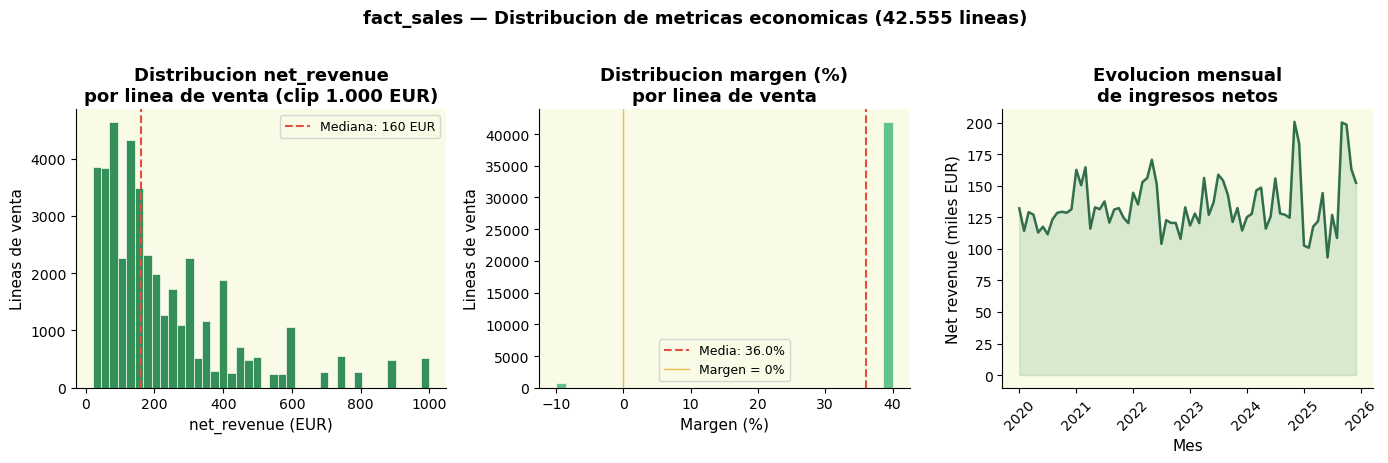

Guardado: graficos/etl_08_factsales.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Plot 1: histograma net_revenue por linea ──────────────────────────────
axes[0].hist(fact_sales['net_revenue'].clip(upper=1000), bins=40, color=G2,
             edgecolor='white', linewidth=0.5, alpha=0.9)
mediana_rev = fact_sales['net_revenue'].median()
axes[0].axvline(mediana_rev, color=G5, linestyle='--', linewidth=1.5,
                label=f'Mediana: {mediana_rev:.0f} EUR')
axes[0].set_title('Distribucion net_revenue\npor linea de venta (clip 1.000 EUR)', fontweight='bold')
axes[0].set_xlabel('net_revenue (EUR)')
axes[0].set_ylabel('Lineas de venta')
axes[0].legend(fontsize=9)

# ── Plot 2: histograma margin_pct ─────────────────────────────────────────
axes[1].hist(fact_sales['margin_pct'].clip(-10, 80), bins=35, color=G3,
             edgecolor='white', linewidth=0.5, alpha=0.9)
media_marg = fact_sales['margin_pct'].mean()
axes[1].axvline(media_marg, color=G5, linestyle='--', linewidth=1.5,
                label=f'Media: {media_marg:.1f}%')
axes[1].axvline(0, color=G6, linestyle='-', linewidth=1, alpha=0.7, label='Margen = 0%')
axes[1].set_title('Distribucion margen (%)\npor linea de venta', fontweight='bold')
axes[1].set_xlabel('Margen (%)')
axes[1].set_ylabel('Lineas de venta')
axes[1].legend(fontsize=9)

# ── Plot 3: evolucion mensual de ingresos ─────────────────────────────────
fact_sales_tmp = fact_sales.copy()
fact_sales_tmp['year']  = fact_sales_tmp['date_id'] // 10000
fact_sales_tmp['month'] = (fact_sales_tmp['date_id'] // 100) % 100
mensual = fact_sales_tmp.groupby(['year','month'])['net_revenue'].sum().reset_index()
mensual['periodo'] = pd.to_datetime(
    mensual['year'].astype(str) + '-' + mensual['month'].astype(str).str.zfill(2) + '-01'
)
axes[2].plot(mensual['periodo'], mensual['net_revenue'] / 1000,
             color=G1, linewidth=1.8, alpha=0.85)
axes[2].fill_between(mensual['periodo'], mensual['net_revenue'] / 1000,
                     alpha=0.15, color=G2)
axes[2].set_title('Evolucion mensual\nde ingresos netos', fontweight='bold')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Net revenue (miles EUR)')
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle('fact_sales — Distribucion de metricas economicas (42.555 lineas)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/etl_08_factsales.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/etl_08_factsales.png')

---
## 9. Validaciones pre-carga

Antes de escribir en el DWH verificamos que los datos transformados son correctos:

1. **Integridad referencial** — Todas las FKs de `fact_sales` apuntan a filas que existen en sus dimensiones
2. **Sin NULLs en FKs** — Las columnas clave no pueden tener valores nulos
3. **Cuadre de ingresos** — La suma de `net_revenue` debe coincidir con los ingresos del OLTP
4. **Conteo de filas** — 42.555 líneas de venta

> Si alguna validación falla, el notebook lanza una excepción y **no carga al DWH**.

In [19]:
checks = []  # lista de (nombre, resultado: bool, detalle)

# ── CHECK 1: sin NULLs en FKs ────────────────────────────────────────────
fk_cols = ['customer_id','product_id','store_id','date_id','offer_id','reason_id']
nulos_fk = fact_sales[fk_cols].isnull().sum().sum()
checks.append(('Sin NULLs en FKs', nulos_fk == 0,
               f'{nulos_fk} nulos encontrados' if nulos_fk else '0 nulos en 6 FKs'))

# ── CHECK 2: integridad referencial customer_id ───────────────────────────
ids_ok = set(dim_customer['customer_id'])
huerfanos_cust = fact_sales['customer_id'].isin(ids_ok)
n_horf_c = (~huerfanos_cust).sum()
checks.append(('FK customer_id valida', n_horf_c == 0,
               f'{n_horf_c} huerfanos' if n_horf_c else 'Todos validos'))

# ── CHECK 3: integridad referencial product_id ────────────────────────────
ids_prod = set(dim_product['product_id'])
n_horf_p = (~fact_sales['product_id'].isin(ids_prod)).sum()
checks.append(('FK product_id valida', n_horf_p == 0,
               f'{n_horf_p} huerfanos' if n_horf_p else 'Todos validos'))

# ── CHECK 4: integridad referencial date_id ───────────────────────────────
ids_date = set(dim_date['date_id'])
n_horf_d = (~fact_sales['date_id'].isin(ids_date)).sum()
checks.append(('FK date_id valida', n_horf_d == 0,
               f'{n_horf_d} huerfanos' if n_horf_d else 'Todos validos'))

# ── CHECK 5: integridad referencial store_id ──────────────────────────────
ids_store = set(dim_store['store_id'])
n_horf_s = (~fact_sales['store_id'].isin(ids_store)).sum()
checks.append(('FK store_id valida', n_horf_s == 0,
               f'{n_horf_s} huerfanos' if n_horf_s else 'Todos validos'))

# ── CHECK 6: integridad referencial offer_id ──────────────────────────────
ids_offer = set(dim_offer['offer_id'])
n_horf_o = (~fact_sales['offer_id'].isin(ids_offer)).sum()
checks.append(('FK offer_id valida', n_horf_o == 0,
               f'{n_horf_o} huerfanos' if n_horf_o else 'Todos validos'))

# ── CHECK 7: integridad referencial reason_id ─────────────────────────────
ids_reason = set(dim_return_reason['reason_id'])
n_horf_r = (~fact_sales['reason_id'].isin(ids_reason)).sum()
checks.append(('FK reason_id valida', n_horf_r == 0,
               f'{n_horf_r} huerfanos' if n_horf_r else 'Todos validos'))

# ── CHECK 8: cuadre de subtotales ────────────────────────────────────────
TOTAL_ESPERADO = 9_678_678.67
total_calc = round(float(fact_sales['subtotal'].sum()), 2)
dif = abs(total_calc - TOTAL_ESPERADO)
checks.append(('Cuadre ingresos OLTP=DWH', dif < 1.0,
               f'OLTP={TOTAL_ESPERADO:,.2f} | DWH={total_calc:,.2f} | Dif={dif:.2f} EUR'))

# ── CHECK 9: conteo de filas ─────────────────────────────────────────────
n_fact = len(fact_sales)
checks.append(('Filas fact_sales = 42.555', n_fact == 42555,
               f'{n_fact:,} filas'))

# ── Mostrar resultados ───────────────────────────────────────────────────
print('=' * 60)
print('VALIDACIONES PRE-CARGA')
print('=' * 60)
all_ok = True
for nombre, ok, detalle in checks:
    simbolo = 'OK' if ok else 'FALLO'
    print(f'  [{simbolo}] {nombre:<35} {detalle}')
    if not ok:
        all_ok = False
print('=' * 60)

if not all_ok:
    raise AssertionError('Hay validaciones fallidas — revisar antes de cargar al DWH.')
else:
    print('Todas las validaciones superadas. Listo para cargar al DWH.')

VALIDACIONES PRE-CARGA
  [OK] Sin NULLs en FKs                    0 nulos en 6 FKs
  [OK] FK customer_id valida               Todos validos
  [OK] FK product_id valida                Todos validos
  [OK] FK date_id valida                   Todos validos
  [OK] FK store_id valida                  Todos validos
  [OK] FK offer_id valida                  Todos validos
  [OK] FK reason_id valida                 Todos validos
  [OK] Cuadre ingresos OLTP=DWH            OLTP=9,678,678.67 | DWH=9,678,678.67 | Dif=0.00 EUR
  [OK] Filas fact_sales = 42.555           42,555 filas
Todas las validaciones superadas. Listo para cargar al DWH.


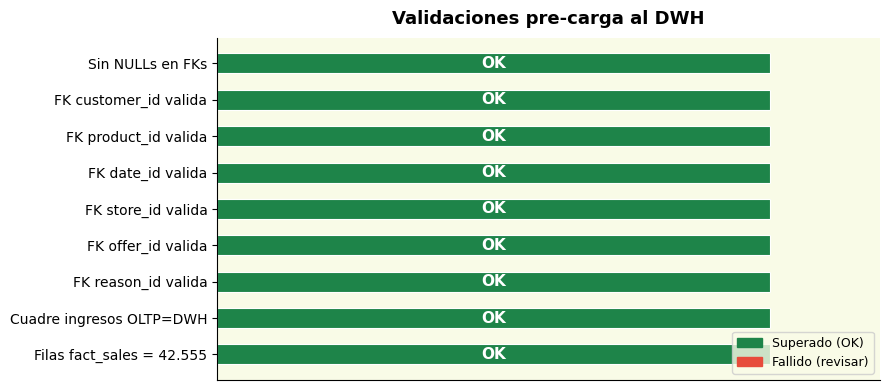

Guardado: graficos/etl_09_validaciones.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 4))

nombres_checks = [c[0] for c in checks]
resultados     = [1 if c[1] else 0 for c in checks]
colores_checks = [G2 if r == 1 else G5 for r in resultados]
etiquetas      = ['OK' if r == 1 else 'FALLO' for r in resultados]

bars = ax.barh(nombres_checks[::-1], [1]*len(checks),
               color=colores_checks[::-1], edgecolor='white', linewidth=0.8, height=0.55)
for i, (bar, etiq) in enumerate(zip(bars, etiquetas[::-1])):
    ax.text(0.5, bar.get_y() + bar.get_height()/2, etiq,
            ha='center', va='center', fontsize=11,
            color='white', fontweight='bold')

ax.set_xlim(0, 1.2)
ax.set_xticks([])
ax.set_title('Validaciones pre-carga al DWH', fontsize=13, fontweight='bold', pad=10)
ok_patch   = mpatches.Patch(color=G2, label='Superado (OK)')
fail_patch = mpatches.Patch(color=G5, label='Fallido (revisar)')
ax.legend(handles=[ok_patch, fail_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('graficos/etl_09_validaciones.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/etl_09_validaciones.png')

---
## 10. Carga al DWH — TRUNCATE + INSERT

El ETL es **idempotente** gracias a `TRUNCATE TABLE ... RESTART IDENTITY CASCADE`:
antes de cada INSERT se vacía la tabla (junto con las tablas que dependen de ella
vía claves foráneas), de modo que re-ejecutar el notebook no duplica datos.

**Orden de carga (respeto a las FKs):**
1. Dimensiones primero (sin FK salientes excepto hacia sí mismas)
2. `fact_sales` al final (depende de las 6 dimensiones)

> Las filas centinela `-1` de `dim_offer` y `dim_return_reason` están
> incluidas en los DataFrames, por lo que se insertan con el resto de filas.

In [21]:
def cargar_tabla(df, tabla, schema='dwh', verbose=True):
    """TRUNCATE + INSERT en una sola transaccion por tabla."""
    with engine.begin() as conn:
        conn.execute(text(f'TRUNCATE TABLE {schema}.{tabla} RESTART IDENTITY CASCADE'))
        df.to_sql(
            name=tabla,
            con=conn,
            schema=schema,
            if_exists='append',
            index=False,
            method='multi',
            chunksize=1000,
        )
    with engine.connect() as conn:
        n = conn.execute(text(f'SELECT COUNT(*) FROM {schema}.{tabla}')).scalar()
    if verbose:
        print(f'  {schema}.{tabla:<22} → {n:>6} filas')
    return n

print('Funcion cargar_tabla definida.')
print('Orden de carga:')
print('  1. dim_date  2. dim_customer  3. dim_product')
print('  4. dim_store  5. dim_offer  6. dim_return_reason')
print('  7. fact_sales (ultima — tiene FKs a todas las dims)')

Funcion cargar_tabla definida.
Orden de carga:
  1. dim_date  2. dim_customer  3. dim_product
  4. dim_store  5. dim_offer  6. dim_return_reason
  7. fact_sales (ultima — tiene FKs a todas las dims)


Iniciando carga al DWH...
  dwh.dim_date               →   2191 filas
  dwh.dim_customer           →   5750 filas
  dwh.dim_product            →     50 filas
  dwh.dim_store              →     20 filas
  dwh.dim_offer              →      2 filas
  dwh.dim_return_reason      →      7 filas
  dwh.fact_sales             →  42555 filas
Total filas cargadas: 50,575


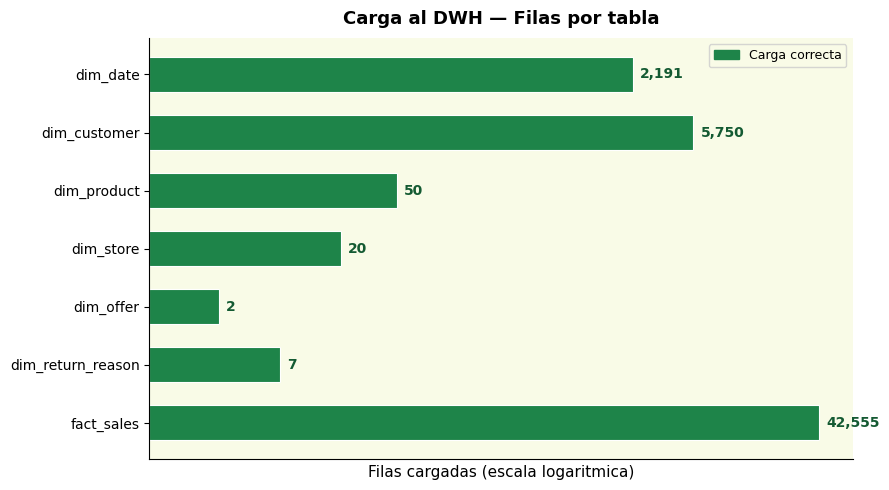

Guardado: graficos/etl_10_carga.png


In [22]:
print('Iniciando carga al DWH...')
print('=' * 50)

resultados_carga = {}
resultados_carga['dim_date']           = cargar_tabla(dim_date,          'dim_date')
resultados_carga['dim_customer']       = cargar_tabla(dim_customer,      'dim_customer')
resultados_carga['dim_product']        = cargar_tabla(dim_product,       'dim_product')
resultados_carga['dim_store']          = cargar_tabla(dim_store,         'dim_store')
resultados_carga['dim_offer']          = cargar_tabla(dim_offer,         'dim_offer')
resultados_carga['dim_return_reason']  = cargar_tabla(dim_return_reason, 'dim_return_reason')
resultados_carga['fact_sales']         = cargar_tabla(fact_sales,        'fact_sales')

print('=' * 50)
print(f'Total filas cargadas: {sum(resultados_carga.values()):,}')

# ── Visualización de la carga ─────────────────────────────────────────────
ESPERADOS = {
    'dim_date': 2191, 'dim_customer': 5750, 'dim_product': 50,
    'dim_store': 20,  'dim_offer': 2, 'dim_return_reason': 7,
    'fact_sales': 42555,
}
tablas_carga = list(resultados_carga.keys())
n_cargadas   = list(resultados_carga.values())
n_esperadas  = [ESPERADOS[t] for t in tablas_carga]
colores_carga = [G2 if r == e else G5 for r, e in zip(n_cargadas, n_esperadas)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(tablas_carga[::-1], [np.log10(n+1) for n in n_cargadas[::-1]],
               color=colores_carga[::-1], edgecolor='white', linewidth=0.8, height=0.6)
for bar, val in zip(bars, n_cargadas[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, color=G1, fontweight='bold')
ax.set_xlabel('Filas cargadas (escala logaritmica)')
ax.set_title('Carga al DWH — Filas por tabla', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks([])
ok_patch = mpatches.Patch(color=G2, label='Carga correcta')
ax.legend(handles=[ok_patch], fontsize=9)
plt.tight_layout()
plt.savefig('graficos/etl_10_carga.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/etl_10_carga.png')

---
## 11. Verificación final

Consultamos directamente el DWH para confirmar que los datos llegaron correctamente.
La prueba definitiva es que **los ingresos del OLTP y del DWH sean idénticos**.

VERIFICACION FINAL — DWH
  dwh.dim_date               esperado=  2191  real=  2191  [OK]
  dwh.dim_customer           esperado=  5750  real=  5750  [OK]
  dwh.dim_product            esperado=    50  real=    50  [OK]
  dwh.dim_store              esperado=    20  real=    20  [OK]
  dwh.dim_offer              esperado=     2  real=     2  [OK]
  dwh.dim_return_reason      esperado=     7  real=     7  [OK]
  dwh.fact_sales             esperado= 42555  real= 42555  [OK]

  Subtotal OLTP:    9,678,678.67 EUR
  Subtotal DWH:     9,678,678.67 EUR
  Diferencia:               0.00 EUR  [OK]


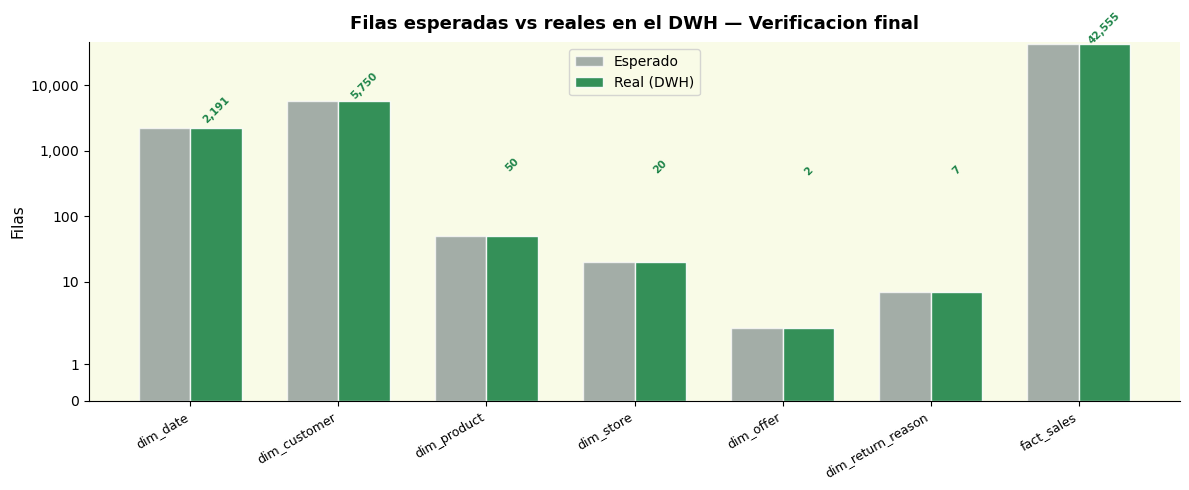


  ETL completado con exito.
  7 tablas DWH cargadas correctamente.
  Ingresos verificados: 9,678,678.67 EUR
  El DWH esta listo para las fases de CLTV y Clustering.


In [23]:
print('=' * 62)
print('VERIFICACION FINAL — DWH')
print('=' * 62)

ESPERADOS_FINAL = {
    'dim_date':          2191,
    'dim_customer':      5750,
    'dim_product':         50,
    'dim_store':           20,
    'dim_offer':            2,
    'dim_return_reason':    7,
    'fact_sales':       42555,
}
conteos_reales = {}

with engine.connect() as conn:
    for tabla, n_esp in ESPERADOS_FINAL.items():
        n_real = conn.execute(text(f'SELECT COUNT(*) FROM dwh.{tabla}')).scalar()
        conteos_reales[tabla] = n_real
        ok = 'OK' if n_real == n_esp else 'REVISAR'
        print(f'  dwh.{tabla:<22} esperado={n_esp:>6}  real={n_real:>6}  [{ok}]')

    # Verificacion de ingresos
    total_dwh = float(conn.execute(text('SELECT SUM(subtotal) FROM dwh.fact_sales')).scalar())
    total_oltp = float(df_sale_item['subtotal'].sum())
    dif = abs(total_dwh - total_oltp)
    ok_ing = 'OK' if dif < 1.0 else 'REVISAR'
    print(f'\n  Subtotal OLTP:  {total_oltp:>14,.2f} EUR')
    print(f'  Subtotal DWH:   {total_dwh:>14,.2f} EUR')
    print(f'  Diferencia:     {dif:>14,.2f} EUR  [{ok_ing}]')

print('=' * 62)

# ── Grafico comparativo esperado vs real ─────────────────────────────────
tablas_v = list(ESPERADOS_FINAL.keys())
esp_v    = list(ESPERADOS_FINAL.values())
real_v   = [conteos_reales[t] for t in tablas_v]
x        = np.arange(len(tablas_v))
w        = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, esp_v,  width=w, color=G7, alpha=0.7, label='Esperado', edgecolor='white')
ax.bar(x + w/2, real_v, width=w, color=G2, alpha=0.9, label='Real (DWH)', edgecolor='white')

for xi, (e, r) in enumerate(zip(esp_v, real_v)):
    color_text = G2 if e == r else G5
    ax.text(xi + w/2, r + max(real_v) * 0.01, f'{r:,}',
            ha='center', fontsize=7.5, color=color_text, fontweight='bold', rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(tablas_v, rotation=30, ha='right', fontsize=9)
ax.set_title('Filas esperadas vs reales en el DWH — Verificacion final',
             fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Filas')
ax.set_yscale('symlog')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y):,}'))

plt.tight_layout()
plt.savefig('graficos/etl_11_verificacion.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

# ── Resumen final ─────────────────────────────────────────────────────────
todos_ok = all(conteos_reales[t] == ESPERADOS_FINAL[t] for t in tablas_v) and dif < 1.0
if todos_ok:
    print()
    print('  ETL completado con exito.')
    print('  7 tablas DWH cargadas correctamente.')
    print(f'  Ingresos verificados: {total_dwh:,.2f} EUR')
    print('  El DWH esta listo para las fases de CLTV y Clustering.')
else:
    print('  ATENCION: hay discrepancias. Revisar los checks anteriores.')

---
## Resumen del ETL

| Tabla DWH | Origen OLTP | Transformacion principal | Filas |
|-----------|-------------|--------------------------|------|
| `dim_date` | Generada | Calendario completo 2020–2025 con atributos temporales | 2.191 |
| `dim_customer` | `customer` | Imputacion de nulos, correc. emails, primera/ultima compra | 5.750 |
| `dim_product` | `product` + `central_product` | Cruce por ID, imputacion unit_cost, calculo margin_pct | 50 |
| `dim_store` | `store` + `city_zone` | Enriquecimiento con distrito y tipo de zona | 20 |
| `dim_offer` | `offer` | Carga directa + fila centinela -1 (sin oferta) | 2 |
| `dim_return_reason` | `return_reason` | Carga directa + fila centinela -1 (sin devolucion) | 7 |
| `fact_sales` | `sale_item` + `sale` + dims | Metricas: descuento, margen, devolucion, flag total | 42.555 |

**Verificacion clave:** `SUM(fact_sales.subtotal)` = `SUM(sale_item.subtotal)` = **9.678.678,67 EUR**

El DWH esta listo para la **Fase 5 — CLTV** y la **Fase 6 — PCA + Clustering**.